<a href="https://colab.research.google.com/github/Viishnu07/DLI_GroupAE_URLPhishing/blob/main/Victor_Individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Setup & (Optional) Google Drive Mount

In [21]:

# Detect Colab
IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    pass

# Mount Google Drive if in Colab (so we can load/save files there)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# Optional: install xgboost if not available (Colab has it preinstalled sometimes)
try:
    import xgboost  # noqa: F401
except Exception:
    if IN_COLAB:
        !pip -q install xgboost
    else:
        print("xgboost not installed here; it's optional and will be skipped if unavailable.")

print("Colab:", IN_COLAB)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True


## 2) Choose Data Source (CSV or ARFF ➜ CSV)

In [22]:
from pathlib import Path
import pandas as pd

# === Configure your data source here ===
# Options:
#   DATA_SOURCE = "csv"  and set CSV_PATH
#   DATA_SOURCE = "arff" and set ARFF_PATH  (will convert to CSV at CSV_PATH_OUT)
DATA_SOURCE = "csv"  # "csv" or "arff"

# If CSV: put your path here (Colab example paths shown)
CSV_PATH = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/Victor/Datasets.csv"

# If ARFF: put your input ARFF path and desired CSV output path
ARFF_PATH = Path("Training Dataset.arff")
CSV_PATH_OUT = Path("Training_Dataset_Cleaned.csv")

# === Load or convert ===
if DATA_SOURCE.lower() == "csv":
    # Check if it's a URL or a local path before asserting existence
    if str(CSV_PATH).startswith("http"):
        df = pd.read_csv(CSV_PATH)
    else:
        assert Path(CSV_PATH).exists(), f"CSV not found at {CSV_PATH}. Please upload or set the correct path."
        df = pd.read_csv(CSV_PATH)
elif DATA_SOURCE.lower() == "arff":
    try:
        from scipy.io import arff
    except Exception as e:
        raise ImportError("scipy is required to read ARFF. In Colab, run: !pip install scipy") from e
    assert ARFF_PATH.exists(), f"ARFF not found at {ARFF_PATH}. Please upload or set the correct path."
    data, meta = arff.loadarff(str(ARFF_PATH))
    import pandas as pd
    df = pd.DataFrame(data)
    # Decode byte strings to normal strings
    for col in df.select_dtypes([object]).columns:
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    # Save to CSV for consistency
    df.to_csv(CSV_PATH_OUT, index=False)
    print(f"Converted ARFF ➜ CSV at: {CSV_PATH_OUT.resolve()}")
    CSV_PATH = CSV_PATH_OUT
else:
    raise ValueError("DATA_SOURCE must be 'csv' or 'arff'")

print("Loaded dataset shape:", df.shape)
display(df.head())

Loaded dataset shape: (11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 3) Quick EDA

In [24]:
import numpy as np

assert 'Result' in df.columns, "Expected a 'Result' column as the target."
print("DTypes (first few):")
print(df.dtypes.head())

print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nClass balance (raw target values):")
print(df['Result'].value_counts())

# Optional numeric summary
display(df.describe(include=[np.number]).T.head(10))

DTypes (first few):
having_IP_Address           int64
URL_Length                  int64
Shortining_Service          int64
having_At_Symbol            int64
double_slash_redirecting    int64
dtype: object

Missing values (top 10):
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
dtype: int64

Class balance (raw target values):
Result
 1    6157
-1    4898
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


## 4) Train/Validation/Test Split

In [26]:
from sklearn.model_selection import train_test_split

# Map target from {-1, 1} -> {0, 1}
y = df['Result'].map({-1:0, 1:1}) # Assuming Type column contains 0 or 1 based on EDA
if y.isnull().any():
    raise ValueError("Found unexpected target values; expected only 0 and 1 based on EDA.")

X = df.drop(columns=['Result']).copy()

# Basic NA handling (forward/back fill)
X = X.fillna(method='ffill').fillna(method='bfill')

# Holdout test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Internal validation from training
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Shapes -> Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())

Shapes -> Train: (7075, 30)  Val: (1769, 30)  Test: (2211, 30)
Train class balance: {1: 0.557, 0: 0.443}


/tmp/ipython-input-3710471523.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(method='bfill')


## 5) Train Candidate Models & Tune F1 Threshold

In [27]:

from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def tune_threshold_for_f1(model, X_tr, y_tr, X_va, y_va, low=0.48, high=0.62, steps=15):
    model.fit(X_tr, y_tr)
    # get probabilities or decision function scaled to [0,1]
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_va)[:,1]
    elif hasattr(model, "decision_function"):
        dec = model.decision_function(X_va)
        proba = (dec - dec.min()) / (dec.max() - dec.min() + 1e-12)
    else:
        y_pred = model.predict(X_va)
        return 0.5, f1_score(y_va, y_pred), precision_score(y_va, y_pred), recall_score(y_va, y_pred)

    ths = np.linspace(low, high, steps)
    best = (0.5, -1.0, 0.0, 0.0)
    for t in ths:
        yp = (proba >= t).astype(int)
        f1t = f1_score(y_va, yp)
        if f1t > best[1]:
            best = (t, f1t, precision_score(y_va, yp), recall_score(y_va, yp))
    return best  # (thr, f1, prec, rec)

# Candidates
candidates = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=200))
    ]),
    "RandomForest": RandomForestClassifier(n_estimators=400, max_depth=20, max_features="sqrt", random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(learning_rate=0.07, max_depth=6, max_iter=180, max_leaf_nodes=31, random_state=42),
}

# Try adding XGBoost if available
try:
    from xgboost import XGBClassifier
    candidates["XGBoost"] = XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.07,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        tree_method="hist", random_state=42, n_jobs=-1, eval_metric="logloss"
    )
except Exception as e:
    print("XGBoost not available:", e)

val_results = {}
for name, model in candidates.items():
    thr, f1v, pv, rv = tune_threshold_for_f1(model, X_train, y_train, X_val, y_val)
    val_results[name] = {"best_thr": float(thr), "val_f1": float(f1v), "val_precision": float(pv), "val_recall": float(rv)}

print("Validation results:")
for k, v in val_results.items():
    print(k, "=>", v)

# Select best by validation F1
best_name = max(val_results.items(), key=lambda kv: kv[1]["val_f1"])[0]
best_thr = val_results[best_name]["best_thr"]
best_model = candidates[best_name]
print("\nSelected best model:", best_name, "with tuned threshold:", round(best_thr, 3))

Validation results:
LogisticRegression => {'best_thr': 0.6, 'val_f1': 0.9312114989733059, 'val_precision': 0.9418483904465212, 'val_recall': 0.9208121827411168}
RandomForest => {'best_thr': 0.57, 'val_f1': 0.9766022380467956, 'val_precision': 0.9785932721712538, 'val_recall': 0.9746192893401016}
HistGradientBoosting => {'best_thr': 0.49, 'val_f1': 0.9670552458185504, 'val_precision': 0.9655870445344129, 'val_recall': 0.9685279187817258}
XGBoost => {'best_thr': 0.5, 'val_f1': 0.9695740365111561, 'val_precision': 0.9685916919959473, 'val_recall': 0.9705583756345177}

Selected best model: RandomForest with tuned threshold: 0.57


## 6) Retrain Best on Full Train ➜ Evaluate on Test

{'test_f1': 0.9785164167004459, 'precision': 0.9765372168284789, 'recall': 0.9805036555645816}

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       980
           1       0.98      0.98      0.98      1231

    accuracy                           0.98      2211
   macro avg       0.98      0.98      0.98      2211
weighted avg       0.98      0.98      0.98      2211



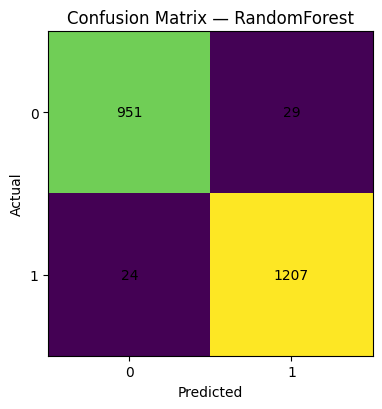

In [28]:

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

best_model.fit(X_train_full, y_train_full)

# Predict on test with tuned threshold
if hasattr(best_model, "predict_proba"):
    proba_test = best_model.predict_proba(X_test)[:,1]
elif hasattr(best_model, "decision_function"):
    dec = best_model.decision_function(X_test)
    proba_test = (dec - dec.min()) / (dec.max() - dec.min() + 1e-12)
else:
    proba_test = None

if proba_test is None:
    y_pred_test = best_model.predict(X_test)
else:
    y_pred_test = (proba_test >= best_thr).astype(int)

test_f1 = f1_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test)
test_rec = recall_score(y_test, y_pred_test)
print({"test_f1": test_f1, "precision": test_prec, "recall": test_rec})
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

# Confusion matrix plot — one chart, no specific colors
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.imshow(cm)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
plt.tight_layout(); plt.show()

## 7) (Optional) Feature Importance

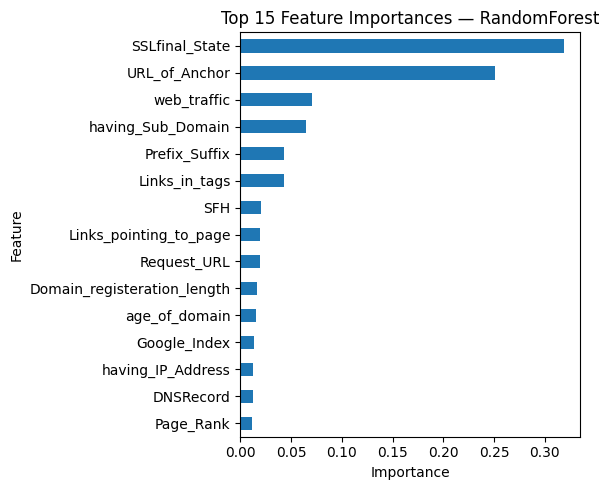

In [29]:

import pandas as pd

if hasattr(best_model, "feature_importances_"):
    # Native feature importances (e.g., RF, XGB)
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    topk = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(6, 5))
    topk.iloc[::-1].plot(kind='barh', ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_name}")
    ax.set_xlabel("Importance"); ax.set_ylabel("Feature")
    plt.tight_layout(); plt.show()
else:
    print(f"Feature importances not available for {best_name}. You can compute permutation_importance if needed (may be slow).")

## 8) Save Artifacts & Inference Helper

In [30]:

import json, joblib

# Where to save (Drive if in Colab, else local folder)
if IN_COLAB:
    SAVE_DIR = Path('/content/drive/MyDrive/phishing_final_artifacts')
else:
    SAVE_DIR = Path('./phishing_final_artifacts')

SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, SAVE_DIR / 'best_model.pkl')
json.dump({"threshold": float(best_thr)}, open(SAVE_DIR / 'threshold.json', 'w'))
json.dump(X.columns.tolist(), open(SAVE_DIR / 'feature_names.json', 'w'))

print("Saved files:")
for p in (SAVE_DIR / '').glob("*"):
    print(" -", p.name)

print("\nUse this snippet for inference:")
print("""
import joblib, json, pandas as pd, numpy as np
model = joblib.load('best_model.pkl')
thr = json.load(open('threshold.json'))['threshold']
feature_names = json.load(open('feature_names.json'))
# X_new must be a DataFrame with the same columns in the same order
# proba:
if hasattr(model, 'predict_proba'):
    proba = model.predict_proba(X_new)[:,1]
elif hasattr(model, 'decision_function'):
    dec = model.decision_function(X_new)
    proba = (dec - dec.min()) / (dec.max() - dec.min() + 1e-12)
y_pred = (proba >= thr).astype(int)
print('Predictions:', y_pred)
""")

Saved files:
 - best_model.pkl
 - threshold.json
 - feature_names.json

Use this snippet for inference:

import joblib, json, pandas as pd, numpy as np
model = joblib.load('best_model.pkl')
thr = json.load(open('threshold.json'))['threshold']
feature_names = json.load(open('feature_names.json'))
# X_new must be a DataFrame with the same columns in the same order
# proba:
if hasattr(model, 'predict_proba'):
    proba = model.predict_proba(X_new)[:,1]
elif hasattr(model, 'decision_function'):
    dec = model.decision_function(X_new)
    proba = (dec - dec.min()) / (dec.max() - dec.min() + 1e-12)
y_pred = (proba >= thr).astype(int)
print('Predictions:', y_pred)



## 9) Hyperparameter Tuning with RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'max_depth': [10, 20, 30, 40, 50, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled. Increase for more thorough search.
    cv=3,  # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1' # Optimize for F1 score
)

# Fit RandomizedSearchCV to the full training data
random_search.fit(X_train_full, y_train_full)

# Get the best parameters and best model
best_params = random_search.best_params_
tuned_best_model = random_search.best_estimator_

print("Best parameters found by RandomizedSearchCV:", best_params)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
